# HNSW Retrieval — SciFact (BEIR)
Replaces every FAISS call with your custom HNSW index.
Covers three embedding types:
- **BERT** (`all-MiniLM-L6-v2`, 384-d)
- **BERT + Cross-Encoder reranker**
- **Word2Vec** (300-d)

Metrics reported: `Precision@k` and `Recall@k` for each pipeline.

## 0 · Imports & sanity-check HNSW extension

In [1]:
import os, pickle, string, time
import numpy as np
import torch
from tqdm.notebook import tqdm
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# ── your compiled HNSW extension ──────────────────────────────────────────
import sys
sys.path.insert(0, r"C:\Users\Chaitanya's Laptop\Desktop\Data_Science\my_algos")
import hnsw_index
print("hnsw_index loaded:", hnsw_index)

hnsw_index loaded: <module 'hnsw_index' from "C:\\Users\\Chaitanya's Laptop\\Desktop\\Data_Science\\my_algos\\hnsw_index.cp310-win_amd64.pyd">


## 1 · Load BEIR SciFact (corpus, queries, qrels)

In [2]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader

dataset_name = "scifact"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset_name}.zip"
out_dir = os.path.join(os.getcwd(), "datasets")
data_path = util.download_and_unzip(url, out_dir)

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

# Flatten corpus into parallel lists (same order every run)
document_ids   = list(corpus.keys())
documents_text = [
    corpus[doc_id].get("title", "") + " " + corpus[doc_id].get("text", "")
    for doc_id in document_ids
]

print(f"Corpus : {len(document_ids):,} documents")
print(f"Queries: {len(queries):,}")
print(f"QRels  : {len(qrels):,}")

c:\Users\Chaitanya's Laptop\Desktop\Data_Science\.venv\lib\site-packages\beir\util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/5183 [00:00<?, ?it/s]

Corpus : 5,183 documents
Queries: 300
QRels  : 300


## 2 · Shared evaluation helper
One function handles Precision@k and Recall@k for **any** retrieval function.

In [3]:
def evaluate(search_fn, queries_dict, qrels_dict, k=10, desc=""):
    """
    Parameters
    ----------
    search_fn : callable
        Takes (query_text: str, k: int) → list of doc_id strings, nearest-first.
    queries_dict : dict   {query_id: query_text}
    qrels_dict   : dict   {query_id: {doc_id: relevance_score}}
    k            : int    cut-off
    desc         : str    label printed in the summary

    Returns
    -------
    dict with keys precision_at_k, recall_at_k
    """
    total_p = total_r = valid = 0

    for query_id, query_text in tqdm(queries_dict.items(), desc=desc or f"Eval@{k}"):
        if query_id not in qrels_dict:
            continue
        relevant = set(qrels_dict[query_id].keys())
        if not relevant:
            continue
        valid += 1

        retrieved = search_fn(query_text, k)          # list[doc_id]
        hits = sum(1 for d in retrieved if d in relevant)

        total_p += hits / k
        total_r += hits / len(relevant)

    mp = total_p / valid
    mr = total_r / valid
    print(f"\n{'─'*40}")
    print(f"{desc or 'Result'}")
    print(f"  Valid queries evaluated : {valid}")
    print(f"  Mean Precision@{k}      : {mp:.4f}")
    print(f"  Mean Recall@{k}         : {mr:.4f}")
    print(f"{'─'*40}\n")
    return {"precision_at_k": mp, "recall_at_k": mr}

## 3 · Pipeline A — BERT bi-encoder + HNSW

### 3.1 Generate / load BERT embeddings

In [4]:
from sentence_transformers import SentenceTransformer

BERT_EMB_PATH = "bert_embeddings.npy"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if os.path.exists(BERT_EMB_PATH):
    print("Loading cached BERT embeddings...")
    bert_embeddings = np.load(BERT_EMB_PATH).astype("float32")
else:
    bert_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    print("Generating BERT embeddings (this takes ~1 min on GPU)...")
    bert_embeddings = bert_model.encode(
        documents_text, batch_size=32, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True   # L2-normalised → cosine via dot
    ).astype("float32")
    np.save(BERT_EMB_PATH, bert_embeddings)

print(f"BERT embeddings shape: {bert_embeddings.shape}")
# Ensure unit-norm (idempotent if already normalised)
norms = np.linalg.norm(bert_embeddings, axis=1, keepdims=True)
bert_embeddings /= np.where(norms == 0, 1, norms)

Device: cuda
Loading cached BERT embeddings...
BERT embeddings shape: (5183, 384)


### 3.2 Build HNSW index over BERT embeddings

In [5]:
# ── Hyper-parameters ──────────────────────────────────────────────────────
BERT_M   = 16    # connections per layer  (↑ → better recall, more RAM)
BERT_EFC = 200   # ef_construction        (↑ → better graph, slower build)
BERT_EF  = 50    # ef at search time      (↑ → better recall, slower query)

print(f"Building HNSW index over {len(document_ids):,} BERT vectors (dim=384)...")
t0 = time.perf_counter()

bert_index = hnsw_index.HNSWIndex(BERT_M, BERT_EFC, 42)
bert_index.insert_batch(bert_embeddings)

print(f"Done in {time.perf_counter()-t0:.1f}s  →  {bert_index}")

Building HNSW index over 5,183 BERT vectors (dim=384)...
Done in 3.1s  →  <HNSWIndex size=5183 levels=4>


### 3.3 Search function

In [6]:
# Lazy-load bert_model only when needed for query encoding
if 'bert_model' not in dir():
    bert_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def search_bert_hnsw(query_text: str, k: int = 10):
    """
    Encode query → L2-normalise → HNSW search.
    Returns list of doc_id strings, nearest-first.
    """
    q = bert_model.encode([query_text], convert_to_numpy=True,
                          normalize_embeddings=True).astype("float32")[0]
    _, indices = bert_index.search(q, k, ef=max(BERT_EF, k))
    return [document_ids[i] for i in indices]

# Quick smoke-test
sample_q = list(queries.values())[0]
print(f"Query : {sample_q}")
print(f"Top-3 : {search_bert_hnsw(sample_q, k=3)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query : 0-dimensional biomaterials show inductive properties.
Top-3 : ['29638116', '4346436', '3874000']


### 3.4 Evaluate BERT + HNSW

In [7]:
bert_hnsw_metrics = evaluate(
    search_fn=search_bert_hnsw,
    queries_dict=queries,
    qrels_dict=qrels,
    k=10,
    desc="BERT bi-encoder + HNSW"
)

BERT bi-encoder + HNSW:   0%|          | 0/300 [00:00<?, ?it/s]


────────────────────────────────────────
BERT bi-encoder + HNSW
  Valid queries evaluated : 300
  Mean Precision@10      : 0.0880
  Mean Recall@10         : 0.7800
────────────────────────────────────────



## 4 · Pipeline B — BERT + HNSW first-stage + Cross-Encoder reranker

### 4.1 Load cross-encoder

In [8]:
from sentence_transformers.cross_encoder import CrossEncoder

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)
print("Cross-Encoder loaded.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-Encoder loaded.


### 4.2 Two-stage search function

In [9]:
# Internal helper: returns full hit dicts (needed by reranker)
def _search_bert_hnsw_full(query_text: str, k: int):
    q = bert_model.encode([query_text], convert_to_numpy=True,
                          normalize_embeddings=True).astype("float32")[0]
    distances, indices = bert_index.search(q, k, ef=max(BERT_EF, k))
    return [
        {"doc_id": document_ids[idx], "score": float(d), "text": documents_text[idx]}
        for d, idx in zip(distances, indices)
    ]

def search_and_rerank(query_text: str, initial_k: int = 100, final_k: int = 10):
    """
    Stage 1 : HNSW retrieves `initial_k` candidates.
    Stage 2 : Cross-encoder scores each (query, doc) pair.
    Returns list of doc_id strings for the top `final_k`, reranked.
    """
    candidates = _search_bert_hnsw_full(query_text, initial_k)
    if not candidates:
        return []

    pairs  = [[query_text, hit["text"]] for hit in candidates]
    scores = cross_encoder.predict(pairs)               # numpy array

    reranked = sorted(
        zip(scores, candidates),
        key=lambda x: x[0],
        reverse=True
    )
    return [hit["doc_id"] for _, hit in reranked[:final_k]]


# Adapter so evaluate() can call it with (query_text, k)
def search_reranked(query_text: str, k: int = 10):
    return search_and_rerank(query_text, initial_k=max(100, k * 5), final_k=k)

### 4.3 Evaluate BERT + HNSW + Cross-Encoder

In [10]:
reranker_metrics = evaluate(
    search_fn=search_reranked,
    queries_dict=queries,
    qrels_dict=qrels,
    k=10,
    desc="BERT + HNSW + Cross-Encoder reranker"
)

BERT + HNSW + Cross-Encoder reranker:   0%|          | 0/300 [00:00<?, ?it/s]


────────────────────────────────────────
BERT + HNSW + Cross-Encoder reranker
  Valid queries evaluated : 300
  Mean Precision@10      : 0.0917
  Mean Recall@10         : 0.8139
────────────────────────────────────────



## 5 · Pipeline C — Word2Vec + HNSW

### 5.1 Generate / load Word2Vec embeddings

In [11]:
import gensim
from gensim.models import Word2Vec

W2V_EMB_PATH   = "w2v_embeddings.npy"
W2V_MODEL_PATH = "w2v_model.bin"
stop_words = set(stopwords.words("english"))

def tokenize(text: str):
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return [w for w in word_tokenize(text) if w not in stop_words]

def doc_vector(model, tokens):
    valid = [w for w in tokens if w in model.wv.key_to_index]
    return np.mean(model.wv[valid], axis=0) if valid else np.zeros(model.vector_size)

if os.path.exists(W2V_EMB_PATH) and os.path.exists(W2V_MODEL_PATH):
    print("Loading cached Word2Vec embeddings and model...")
    w2v_embeddings = np.load(W2V_EMB_PATH).astype("float32")
    w2v_model = Word2Vec.load(W2V_MODEL_PATH)
else:
    print("Tokenising corpus...")
    tokenized_docs = [tokenize(t) for t in tqdm(documents_text, desc="Tokenise")]

    print("Training Word2Vec...")
    w2v_model = Word2Vec(
        sentences=tokenized_docs, vector_size=300,
        window=5, min_count=2, workers=4
    )
    w2v_model.save(W2V_MODEL_PATH)

    print("Generating document vectors...")
    w2v_embeddings = np.array(
        [doc_vector(w2v_model, tok) for tok in tqdm(tokenized_docs, desc="Embed")],
        dtype="float32"
    )
    np.save(W2V_EMB_PATH, w2v_embeddings)

# L2-normalise for cosine similarity
norms = np.linalg.norm(w2v_embeddings, axis=1, keepdims=True)
w2v_embeddings /= np.where(norms == 0, 1, norms)
print(f"Word2Vec embeddings shape: {w2v_embeddings.shape}")

Loading cached Word2Vec embeddings and model...
Word2Vec embeddings shape: (5183, 300)


### 5.2 Build HNSW index over Word2Vec embeddings

In [12]:
W2V_M   = 16
W2V_EFC = 200
W2V_EF  = 50

print(f"Building HNSW index over {len(document_ids):,} Word2Vec vectors (dim=300)...")
t0 = time.perf_counter()

w2v_hnsw_index = hnsw_index.HNSWIndex(W2V_M, W2V_EFC, 42)
w2v_hnsw_index.insert_batch(w2v_embeddings)

print(f"Done in {time.perf_counter()-t0:.1f}s  →  {w2v_hnsw_index}")

Building HNSW index over 5,183 Word2Vec vectors (dim=300)...
Done in 1.2s  →  <HNSWIndex size=5183 levels=4>


### 5.3 Search function

In [13]:
def search_w2v_hnsw(query_text: str, k: int = 10):
    tokens = tokenize(query_text)
    q = doc_vector(w2v_model, tokens).astype("float32")

    # Normalise query
    norm = np.linalg.norm(q)
    if norm > 0:
        q /= norm

    _, indices = w2v_hnsw_index.search(q, k, ef=max(W2V_EF, k))
    return [document_ids[i] for i in indices]

### 5.4 Evaluate Word2Vec + HNSW

In [14]:
w2v_hnsw_metrics = evaluate(
    search_fn=search_w2v_hnsw,
    queries_dict=queries,
    qrels_dict=qrels,
    k=10,
    desc="Word2Vec + HNSW"
)

Word2Vec + HNSW:   0%|          | 0/300 [00:00<?, ?it/s]


────────────────────────────────────────
Word2Vec + HNSW
  Valid queries evaluated : 300
  Mean Precision@10      : 0.0050
  Mean Recall@10         : 0.0433
────────────────────────────────────────



## 6 · Side-by-side comparison

In [15]:
import pandas as pd

# Your original FAISS numbers (from train.ipynb) for direct comparison
faiss_bert   = {"precision_at_k": 0.0883, "recall_at_k": 0.7833}
faiss_rerank = {"precision_at_k": 0.0917, "recall_at_k": 0.8139}
faiss_w2v    = {"precision_at_k": 0.0057, "recall_at_k": 0.0500}

rows = [
    ("FAISS · BERT bi-encoder",          faiss_bert["precision_at_k"],   faiss_bert["recall_at_k"]),
    ("HNSW · BERT bi-encoder",           bert_hnsw_metrics["precision_at_k"], bert_hnsw_metrics["recall_at_k"]),
    ("FAISS · BERT + Cross-Encoder",     faiss_rerank["precision_at_k"], faiss_rerank["recall_at_k"]),
    ("HNSW · BERT + Cross-Encoder",      reranker_metrics["precision_at_k"],  reranker_metrics["recall_at_k"]),
    ("FAISS · Word2Vec",                 faiss_w2v["precision_at_k"],    faiss_w2v["recall_at_k"]),
    ("HNSW · Word2Vec",                  w2v_hnsw_metrics["precision_at_k"],  w2v_hnsw_metrics["recall_at_k"]),
]

df = pd.DataFrame(rows, columns=["Pipeline", "Precision@10", "Recall@10"])
df = df.set_index("Pipeline")

# Highlight best per metric
display(
    df.style
      .format("{:.10f}")
      .highlight_max(axis=0, color="#024c13")   # green = best
      .set_caption("HNSW vs FAISS — SciFact BEIR test split, k=10")
)

,Precision@10,Recall@10
Pipeline,,
FAISS · BERT bi-encoder,0.0883000000,0.7833000000
HNSW · BERT bi-encoder,0.0880000000,0.7800000000
FAISS · BERT + Cross-Encoder,0.0917000000,0.8139000000
HNSW · BERT + Cross-Encoder,0.0916666667,0.8138888889
FAISS · Word2Vec,0.0057000000,0.0500000000
HNSW · Word2Vec,0.0050000000,0.0433333333


## 7 · ef_search sweep — recall vs speed trade-off (BERT pipeline)

ef= 10  P@10=0.0843  R@10=0.7400    4.56 ms/query
ef= 20  P@10=0.0870  R@10=0.7683    4.85 ms/query
ef= 50  P@10=0.0880  R@10=0.7800    4.57 ms/query
ef=100  P@10=0.0883  R@10=0.7833    6.36 ms/query
ef=200  P@10=0.0883  R@10=0.7833    7.03 ms/query


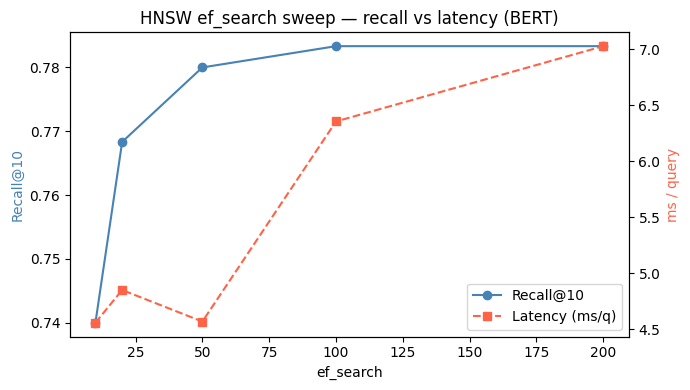

Saved hnsw_ef_sweep.png


In [16]:
import matplotlib.pyplot as plt

EF_VALUES = [10, 20, 50, 100, 200]
K = 10

sweep_results = []
for ef in EF_VALUES:
    total_r = total_p = valid = 0
    t0 = time.perf_counter()

    for query_id, query_text in queries.items():
        if query_id not in qrels:
            continue
        relevant = set(qrels[query_id].keys())
        if not relevant:
            continue
        valid += 1

        q = bert_model.encode([query_text], convert_to_numpy=True,
                              normalize_embeddings=True).astype("float32")[0]
        _, indices = bert_index.search(q, K, ef=ef)
        retrieved = [document_ids[i] for i in indices]
        hits = sum(1 for d in retrieved if d in relevant)

        total_p += hits / K
        total_r += hits / len(relevant)

    elapsed_ms = (time.perf_counter() - t0) * 1000 / valid
    sweep_results.append({
        "ef": ef,
        "precision": total_p / valid,
        "recall":    total_r / valid,
        "ms_per_query": elapsed_ms,
    })
    print(f"ef={ef:3d}  P@{K}={total_p/valid:.4f}  R@{K}={total_r/valid:.4f}  "
          f"  {elapsed_ms:.2f} ms/query")

# ── Plot ──────────────────────────────────────────────────────────────────
efs      = [r["ef"]          for r in sweep_results]
recalls  = [r["recall"]      for r in sweep_results]
latency  = [r["ms_per_query"]for r in sweep_results]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(efs, recalls,  "o-", color="steelblue",  label="Recall@10")
ax2.plot(efs, latency,  "s--",color="tomato",     label="Latency (ms/q)")

ax1.set_xlabel("ef_search");  ax1.set_ylabel("Recall@10",      color="steelblue")
ax2.set_ylabel("ms / query",                                    color="tomato")
ax1.set_title("HNSW ef_search sweep — recall vs latency (BERT)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
plt.tight_layout()
plt.savefig("hnsw_ef_sweep.png", dpi=150)
plt.show()
print("Saved hnsw_ef_sweep.png")